#  ASAP-AES : Automated Essay Scoring avec DeBERTa & CORN

**Objectif** : Prédire automatiquement le score (0-3) de réponses courtes d'étudiants

**Approche** :
-  **Entraînement par question** (un modèle par EssaySet)
-  **Deux architectures** : DeBERTa-v3-small fine-tuné + CORN (régression ordinale)
-  **Métriques** : Quadratic Weighted Kappa (QWK) + Accuracy
-  **Comparaison détaillée** avec graphiques de performance

**Dataset** : ASAP-SAS (Automated Student Assessment Prize - Short Answer Scoring)

---


## **1. Installation et imports**


In [ ]:
# Installation des packages nécessaires
!pip install -q transformers sentence-transformers torch torchvision scikit-learn pandas numpy matplotlib seaborn tqdm

print(' Packages installés')


 Packages installés


In [ ]:
# ── Imports ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sentence_transformers import SentenceTransformer

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f' Device: {device}')
print(f' PyTorch version: {torch.__version__}')


 Device: cuda
 PyTorch version: 2.10.0+cu128


## **2. Fonctions utilitaires**


In [ ]:
def quadratic_weighted_kappa(y_true, y_pred):
    """Calcule le QWK (Cohen's Quadratic Weighted Kappa)."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    min_r = min(y_true.min(), y_pred.min())
    max_r = max(y_true.max(), y_pred.max())
    n = int(max_r - min_r + 1)

    conf = np.zeros((n, n))
    for t, p in zip(y_true, y_pred):
        conf[int(t - min_r), int(p - min_r)] += 1

    w = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            w[i, j] = ((i - j) ** 2) / ((n - 1) ** 2)

    ht = conf.sum(axis=1)
    hp = conf.sum(axis=0)
    exp = np.outer(ht, hp)

    conf /= conf.sum()
    exp /= exp.sum()

    return 1 - (w * conf).sum() / (w * exp).sum()


def clear_memory():
    """Libère la mémoire GPU et RAM."""
    gc.collect()
    torch.cuda.empty_cache()


print(' Fonctions utilitaires définies')


 Fonctions utilitaires définies


## **3. Chargement et exploration des données**


In [ ]:
from google.colab import files

# Upload du fichier
#uploaded = files.upload()
df = pd.read_csv('train.tsv', sep='\t', encoding='utf-8')

print(f' Dataset chargé: {df.shape[0]} réponses, {df.shape[1]} colonnes')
print(f' Colonnes: {list(df.columns)}')
df.head()


 Dataset chargé: 17207 réponses, 5 colonnes
 Colonnes: ['Id', 'EssaySet', 'Score1', 'Score2', 'EssayText']


,Id,EssaySet,Score1,Score2,EssayText
0,1,1,1,1,Some additional information that we would need...
1,2,1,1,1,"After reading the expirement, I realized that ..."
2,3,1,1,1,"What you need is more trials, a control set up..."
3,4,1,0,0,The student should list what rock is better an...
4,5,1,2,2,For the students to be able to make a replicat...


In [ ]:
# ── Exploration rapide ──
print(' Distribution des EssaySets:')
print(df['EssaySet'].value_counts().sort_index())

print('\n Distribution des scores (Score1):')
print(df['Score1'].value_counts().sort_index())

print('\n Nombre de classes par EssaySet:')
for es in sorted(df['EssaySet'].unique()):
    classes = sorted(df[df['EssaySet']==es]['Score1'].unique())
    print(f'  EssaySet {es:2d}: {classes}')


 Distribution des EssaySets:
EssaySet
1     1672
2     1278
3     1891
4     1738
5     1795
6     1797
7     1799
8     1799
9     1798
10    1640
Name: count, dtype: int64

 Distribution des scores (Score1):
Score1
0    6779
1    5612
2    4075
3     741
Name: count, dtype: int64

 Nombre de classes par EssaySet:
  EssaySet  1: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  EssaySet  2: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  EssaySet  3: [np.int64(0), np.int64(1), np.int64(2)]
  EssaySet  4: [np.int64(0), np.int64(1), np.int64(2)]
  EssaySet  5: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  EssaySet  6: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  EssaySet  7: [np.int64(0), np.int64(1), np.int64(2)]
  EssaySet  8: [np.int64(0), np.int64(1), np.int64(2)]
  EssaySet  9: [np.int64(0), np.int64(1), np.int64(2)]
  EssaySet 10: [np.int64(0), np.int64(1), np.int64(2)]


In [ ]:
# ── Nettoyage léger ──
def clean_text(text):
    text = str(text).lower().strip()
    return ' '.join(text.split())  # Normaliser espaces

df['essay_text'] = df['EssayText'].apply(clean_text)
df['score'] = df['Score1']
df['essay_set'] = df['EssaySet']

# Garder seulement les colonnes nécessaires
df = df[['essay_set', 'essay_text', 'score']].copy()

print(f' Données nettoyées: {df.shape}')
df.head()


 Données nettoyées: (17207, 3)


,essay_set,essay_text,score
0,1,some additional information that we would need...,1
1,1,"after reading the expirement, i realized that ...",1
2,1,"what you need is more trials, a control set up...",1
3,1,the student should list what rock is better an...,0
4,1,for the students to be able to make a replicat...,2


In [ ]:
# ── Split stratifié par EssaySet (70/15/15) ──
df_train, df_temp = train_test_split(df, test_size=0.30, random_state=42, stratify=df['essay_set'])
df_val, df_test = train_test_split(df_temp, test_size=0.50, random_state=42, stratify=df_temp['essay_set'])

print(f' Split effectué:')
print(f'  Train: {len(df_train):5d} ({len(df_train)/len(df)*100:.1f}%)')
print(f'  Val  : {len(df_val):5d} ({len(df_val)/len(df)*100:.1f}%)')
print(f'  Test : {len(df_test):5d} ({len(df_test)/len(df)*100:.1f}%)')

# Vérifier stratification
print('\n Distribution par EssaySet:')
for name, dset in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    sets = sorted(dset['essay_set'].unique())
    print(f'  {name:5s}: {sets}')


 Split effectué:
  Train: 12044 (70.0%)
  Val  :  2581 (15.0%)
  Test :  2582 (15.0%)

 Distribution par EssaySet:
  Train: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
  Val  : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
  Test : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


## **4. Feature engineering avec Sentence-BERT**


In [ ]:
# ── Charger SBERT ──
sbert = SentenceTransformer('all-MiniLM-L6-v2')
print(' SBERT chargé (dimension: 384)')

# ── Encoder les ensembles ──
print('\n Encodage des textes...')
train_embeddings = sbert.encode(df_train['essay_text'].tolist(), show_progress_bar=True, convert_to_numpy=True)
val_embeddings = sbert.encode(df_val['essay_text'].tolist(), show_progress_bar=True, convert_to_numpy=True)
test_embeddings = sbert.encode(df_test['essay_text'].tolist(), show_progress_bar=True, convert_to_numpy=True)

print(f'\n Embeddings générés:')
print(f'  Train: {train_embeddings.shape}')
print(f'  Val  : {val_embeddings.shape}')
print(f'  Test : {test_embeddings.shape}')


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

 SBERT chargé (dimension: 384)

 Encodage des textes...


Batches:   0%|          | 0/377 [00:00<?, ?it/s]

Batches:   0%|          | 0/81 [00:00<?, ?it/s]

Batches:   0%|          | 0/81 [00:00<?, ?it/s]


 Embeddings générés:
  Train: (12044, 384)
  Val  : (2581, 384)
  Test : (2582, 384)


## **5. Modèle CORN (Conditional Ordinal Regression)**

CORN est une approche de régression ordinale qui prédit K-1 probabilités conditionnelles :
- P(y = k | y ≥ k) pour k = 0, 1, ..., K-2

**Avantages** :
- Respecte l'ordre naturel des scores (0 < 1 < 2 < 3)
- Pénalise moins les erreurs adjacentes (0→1) que les erreurs extrêmes (0→3)
- Pas de contrainte de poids partagé (contrairement à CORAL)


In [ ]:
class CORNModel(nn.Module):
    def __init__(self, input_dim=384, hidden_dim=128, num_classes=4, dropout=0.3):
        super().__init__()
        self.num_classes = num_classes

        self.trunk = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.heads = nn.ModuleList([nn.Linear(hidden_dim, 1) for _ in range(num_classes - 1)])

    def forward(self, x):
        h = self.trunk(x)
        logits = torch.cat([head(h) for head in self.heads], dim=1)
        return logits

    def predict_proba(self, x):
        logits = self.forward(x)
        sigs = torch.sigmoid(logits)

        probs = []
        remaining = torch.ones(logits.shape[0], 1, device=logits.device)

        for k in range(self.num_classes - 1):
            p_k = remaining * (1.0 - sigs[:, k:k+1])
            probs.append(p_k)
            remaining = remaining * sigs[:, k:k+1]

        probs.append(remaining)
        return torch.cat(probs, dim=1)


def corn_loss(logits, labels, num_classes):
    loss = torch.tensor(0.0, device=logits.device)
    count = 0

    for k in range(num_classes - 1):
        mask = labels >= k
        if mask.sum() == 0:
            continue

        logit_k = logits[mask, k]
        target_k = (labels[mask] > k).float()
        loss += F.binary_cross_entropy_with_logits(logit_k, target_k)
        count += 1

    return loss / max(count, 1)


class EmbeddingDataset(Dataset):
    def __init__(self, embeddings, labels):
        self.X = torch.FloatTensor(embeddings)
        self.y = torch.LongTensor(labels)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {'features': self.X[idx], 'label': self.y[idx]}


print(' CORN model défini')


 CORN model défini


In [ ]:
def train_corn(embeddings_tr, y_tr, embeddings_val, y_val, num_classes,
               epochs=40, lr=0.001, patience=8, batch_size=32):
    """Entraîne CORN sur un EssaySet."""

    train_ds = EmbeddingDataset(embeddings_tr, y_tr)
    val_ds = EmbeddingDataset(embeddings_val, y_val)

    # ── CRITIQUE : drop_last=True pour éviter les batchs de taille 1 ──
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)  # Pas de drop_last en val

    model = CORNModel(input_dim=384, hidden_dim=128, num_classes=num_classes, dropout=0.3).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    best_state = None
    counter = 0
    history = {'train_loss': [], 'val_loss': [], 'val_qwk': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        train_loss = 0.0
        total_samples = 0  # ← Compter les échantillons réellement traités

        for batch in train_dl:
            X = batch['features'].to(device)
            y = batch['label'].to(device)

            logits = model(X)
            loss = corn_loss(logits, y, num_classes)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X.size(0)
            total_samples += X.size(0)

        train_loss /= max(total_samples, 1)  

        # Val
        model.eval()
        val_loss = 0.0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for batch in val_dl:
                X = batch['features'].to(device)
                y = batch['label'].to(device)

                logits = model(X)
                val_loss += corn_loss(logits, y, num_classes).item() * X.size(0)

                probs = model.predict_proba(X)
                preds = probs.argmax(dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y.cpu().numpy())

        val_loss /= len(y_val)
        val_qwk = quadratic_weighted_kappa(all_labels, all_preds)
        val_acc = accuracy_score(all_labels, all_preds)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_qwk'].append(val_qwk)
        history['val_acc'].append(val_acc)

        star = ''
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            counter = 0
            star = ' ⭐'
        else:
            counter += 1
            if counter >= patience:
                break

        if epoch % 5 == 0 or star:
            print(f'    Epoch {epoch:2d} | Loss: {train_loss:.4f} → {val_loss:.4f} | '
                  f'QWK: {val_qwk:.4f} | Acc: {val_acc:.4f}{star}')

    model.load_state_dict(best_state)
    model.to(device)
    return model, history


print(' Fonction train_corn corrigée')

 Fonction train_corn corrigée


## **6. Entraînement CORN par EssaySet**

On entraîne un modèle séparé pour chaque question pour respecter l'hétérogénéité des sujets.


In [ ]:
corn_models = {}

for es in sorted(df_train['essay_set'].unique()):
    print(f'\n{'='*60}')
    print(f'   CORN - EssaySet {es}')
    print(f'{'='*60}')

    # Filtrer données
    train_mask = df_train['essay_set'] == es
    val_mask = df_val['essay_set'] == es

    embeddings_tr = train_embeddings[train_mask]
    y_tr = df_train.loc[train_mask, 'score'].values

    embeddings_val = val_embeddings[val_mask]
    y_val = df_val.loc[val_mask, 'score'].values

    # Mapper scores → indices
    unique_scores = sorted(np.unique(np.concatenate([y_tr, y_val])))
    score_map = {s: i for i, s in enumerate(unique_scores)}
    n_classes = len(unique_scores)

    y_tr_mapped = np.array([score_map[s] for s in y_tr])
    y_val_mapped = np.array([score_map[s] for s in y_val])

    print(f'  Train: {len(y_tr):4d} | Val: {len(y_val):4d} | Classes: {unique_scores} → {n_classes}')

    # Entraîner
    model, history = train_corn(
        embeddings_tr, y_tr_mapped,
        embeddings_val, y_val_mapped,
        num_classes=n_classes,
        epochs=40, lr=0.001, patience=8
    )

    corn_models[es] = (model, history, n_classes, score_map)
    clear_memory()

print(f'\n {len(corn_models)} modèles CORN entraînés')



   CORN - EssaySet 1
  Train: 1170 | Val:  251 | Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)] → 4
    Epoch  1 | Loss: 0.5769 → 0.5973 | QWK: 0.5267 | Acc: 0.4542 ⭐
    Epoch  2 | Loss: 0.4657 → 0.4883 | QWK: 0.6077 | Acc: 0.5339 ⭐
    Epoch  3 | Loss: 0.4103 → 0.4724 | QWK: 0.6626 | Acc: 0.5618 ⭐
    Epoch  4 | Loss: 0.3792 → 0.4567 | QWK: 0.6561 | Acc: 0.5657 ⭐
    Epoch  5 | Loss: 0.3518 → 0.4425 | QWK: 0.7215 | Acc: 0.6016 ⭐
    Epoch  7 | Loss: 0.3031 → 0.4391 | QWK: 0.7365 | Acc: 0.6255 ⭐
    Epoch 10 | Loss: 0.2471 → 0.4484 | QWK: 0.7457 | Acc: 0.6414

   CORN - EssaySet 2
  Train:  895 | Val:  192 | Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)] → 4
    Epoch  1 | Loss: 0.5652 → 0.5577 | QWK: 0.3664 | Acc: 0.3958 ⭐
    Epoch  2 | Loss: 0.4774 → 0.5032 | QWK: 0.5140 | Acc: 0.4167 ⭐
    Epoch  3 | Loss: 0.4333 → 0.4710 | QWK: 0.5600 | Acc: 0.4427 ⭐
    Epoch  4 | Loss: 0.3959 → 0.4630 | QWK: 0.5644 | Acc: 0.4323 ⭐
    Epoch  5 | Loss: 0.3634 → 0.4

## **7. Fine-tuning DeBERTa-v3-small**

DeBERTa-v3-small (44M paramètres) est fine-tuné sur chaque question.
- Architecture : Transformers → [CLS] → Linear(768 → num_classes)
- Loss : CrossEntropyLoss pondérée par classe
- Optimiseur : AdamW avec warmup scheduler


In [ ]:
class DeBERTaDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=96):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }


print(' DeBERTaDataset défini')


 DeBERTaDataset défini


In [ ]:
def train_deberta(texts_tr, y_tr, texts_val, y_val, num_classes,
                  epochs=3, lr=2e-5, batch_size=8, max_len=96):
    """Fine-tune DeBERTa sur un EssaySet."""

    tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-v3-small')
    model = AutoModelForSequenceClassification.from_pretrained(
        'microsoft/deberta-v3-small',
        num_labels=num_classes,
        dtype=torch.float32
    ).to(device)

    train_ds = DeBERTaDataset(texts_tr, y_tr, tokenizer, max_len)
    val_ds = DeBERTaDataset(texts_val, y_val, tokenizer, max_len)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    # Class weights
    counts = np.bincount(y_tr, minlength=num_classes).astype(float)
    counts[counts == 0] = 1
    weights = torch.FloatTensor(len(y_tr) / (num_classes * counts)).to(device)
    criterion = nn.CrossEntropyLoss(weight=weights)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(train_dl) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=total_steps // 10, num_training_steps=total_steps
    )

    best_val_loss = float('inf')
    best_state = None
    history = {'train_loss': [], 'val_loss': [], 'val_qwk': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        train_loss = 0.0

        pbar = tqdm(train_dl, desc=f'Epoch {epoch}/{epochs}', leave=False)
        for batch in pbar:
            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=ids, attention_mask=mask)
            loss = criterion(outputs.logits, labels)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            train_loss += loss.item() * ids.size(0)
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        train_loss /= len(y_tr)

        # Val
        model.eval()
        val_loss = 0.0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for batch in val_dl:
                ids = batch['input_ids'].to(device)
                mask = batch['attention_mask'].to(device)
                labels = batch['label'].to(device)

                outputs = model(input_ids=ids, attention_mask=mask)
                val_loss += criterion(outputs.logits, labels).item() * ids.size(0)

                preds = outputs.logits.argmax(dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss /= len(y_val)
        val_qwk = quadratic_weighted_kappa(all_labels, all_preds)
        val_acc = accuracy_score(all_labels, all_preds)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_qwk'].append(val_qwk)
        history['val_acc'].append(val_acc)

        star = ''
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            star = ' ⭐'

        print(f'    Epoch {epoch} | Loss: {train_loss:.4f} → {val_loss:.4f} | '
              f'QWK: {val_qwk:.4f} | Acc: {val_acc:.4f}{star}')

    model.load_state_dict(best_state)
    model.to(device)
    return model, tokenizer, history


print(' Fonction train_deberta définie')


 Fonction train_deberta définie


## **8. Entraînement DeBERTa par EssaySet**


In [ ]:
def train_deberta(texts_tr, y_tr, texts_val, y_val, num_classes,
                  epochs=3, lr=2e-5, batch_size=8, max_len=96, patience=3):
    """Fine-tune DeBERTa avec Early Stopping."""

    tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-v3-small')
    model = AutoModelForSequenceClassification.from_pretrained(
        'microsoft/deberta-v3-small',
        num_labels=num_classes,
        dtype=torch.float32
    ).to(device)


    train_ds = DeBERTaDataset(texts_tr, y_tr, tokenizer, max_len)
    val_ds = DeBERTaDataset(texts_val, y_val, tokenizer, max_len)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    # Class weights & Optimizer
    counts = np.bincount(y_tr, minlength=num_classes).astype(float)
    counts[counts == 0] = 1
    weights = torch.FloatTensor(len(y_tr) / (num_classes * counts)).to(device)
    criterion = nn.CrossEntropyLoss(weight=weights)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(train_dl) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=total_steps // 10, num_training_steps=total_steps
    )

    # --- LOGIQUE EARLY STOPPING ---
    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'val_qwk': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        
        model.train()
        train_loss = 0.0
        pbar = tqdm(train_dl, desc=f'Epoch {epoch}/{epochs}', leave=False)
        for batch in pbar:
            ids, mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['label'].to(device)
            outputs = model(input_ids=ids, attention_mask=mask)
            loss = criterion(outputs.logits, labels)
            optimizer.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step()
            train_loss += loss.item() * ids.size(0)

        train_loss /= len(y_tr)

        
        model.eval()
        val_loss = 0.0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in val_dl:
                ids, mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['label'].to(device)
                outputs = model(input_ids=ids, attention_mask=mask)
                val_loss += criterion(outputs.logits, labels).item() * ids.size(0)
                preds = outputs.logits.argmax(dim=1)
                all_preds.extend(preds.cpu().numpy()); all_labels.extend(labels.cpu().numpy())

        val_loss /= len(y_val)
        val_qwk = quadratic_weighted_kappa(all_labels, all_preds)
        val_acc = accuracy_score(all_labels, all_preds)

        # --- MISE À JOUR EARLY STOPPING ---
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_qwk'].append(val_qwk)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
            star = ' ⭐'
        else:
            epochs_no_improve += 1
            star = ''

        print(f'    Epoch {epoch} | Loss: {train_loss:.4f} → {val_loss:.4f} | '
              f'QWK: {val_qwk:.4f} | Acc: {val_acc:.4f}{star}')

        if epochs_no_improve >= patience:
            print(f' Early stopping déclenché à l\'époque {epoch} !')
            break

    model.load_state_dict(best_state)
    return model, tokenizer, history

In [ ]:
deberta_models = {}

for es in sorted(df_train['essay_set'].unique()):
    print(f'\n{'='*60}')
    print(f'   DeBERTa - EssaySet {es}')
    print(f'{'='*60}')

    clear_memory()

    # Filtrer
    train_mask = df_train['essay_set'] == es
    val_mask = df_val['essay_set'] == es

    texts_tr = df_train.loc[train_mask, 'essay_text'].tolist()
    y_tr = df_train.loc[train_mask, 'score'].values

    texts_val = df_val.loc[val_mask, 'essay_text'].tolist()
    y_val = df_val.loc[val_mask, 'score'].values

    # Mapper
    unique_scores = sorted(np.unique(np.concatenate([y_tr, y_val])))
    score_map = {s: i for i, s in enumerate(unique_scores)}
    n_classes = len(unique_scores)

    y_tr_mapped = np.array([score_map[s] for s in y_tr])
    y_val_mapped = np.array([score_map[s] for s in y_val])

    print(f'  Train: {len(y_tr):4d} | Val: {len(y_val):4d} | Classes: {unique_scores} → {n_classes}')

    # Entraîner
    model, tokenizer, history = train_deberta(
        texts_tr, y_tr_mapped,
        texts_val, y_val_mapped,
        num_classes=n_classes,
        epochs=60, patience=4, lr=2e-5, batch_size=4 
    )

    deberta_models[es] = (model, tokenizer, history, n_classes, score_map)
    clear_memory()

print(f'\n {len(deberta_models)} modèles DeBERTa entraînés')


   DeBERTa - EssaySet 1
  Train: 1170 | Val:  251 | Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)] → 4


config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/286M [00:00<?, ?B/s]

...

    Epoch 5 | Loss: 0.6026 → 1.0724 | QWK: 0.7118 | Acc: 0.7724


Epoch 6/60:   0%|          | 0/287 [00:00<?, ?it/s]

    Epoch 6 | Loss: 0.5892 → 1.1810 | QWK: 0.7139 | Acc: 0.7683


Epoch 7/60:   0%|          | 0/287 [00:00<?, ?it/s]

    Epoch 7 | Loss: 0.5368 → 1.2225 | QWK: 0.7465 | Acc: 0.7805
 Early stopping déclenché à l'époque 7 !

 10 modèles DeBERTa entraînés


## **9. Prédictions sur le test set**


In [ ]:
def predict_corn(model, embeddings, score_map):
    """Prédictions CORN avec remapping vers scores originaux."""
    model.eval()
    ds = EmbeddingDataset(embeddings, np.zeros(len(embeddings)))
    loader = DataLoader(ds, batch_size=64, shuffle=False)

    all_preds = []
    with torch.no_grad():
        for batch in loader:
            X = batch['features'].to(device)
            probs = model.predict_proba(X)
            preds = probs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())

    preds = np.array(all_preds)
    inv_map = {i: s for s, i in score_map.items()}
    preds_orig = np.array([inv_map[p] for p in preds])
    return preds_orig


def predict_deberta(model, tokenizer, texts, score_map):
    """Prédictions DeBERTa avec remapping vers scores originaux."""
    model.eval()
    ds = DeBERTaDataset(texts, np.zeros(len(texts)), tokenizer, max_len=96)
    loader = DataLoader(ds, batch_size=16, shuffle=False)

    all_preds = []
    with torch.no_grad():
        for batch in loader:
            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)

            outputs = model(input_ids=ids, attention_mask=mask)
            preds = outputs.logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())

    preds = np.array(all_preds)
    inv_map = {i: s for s, i in score_map.items()}
    preds_orig = np.array([inv_map[p] for p in preds])
    return preds_orig


print(' Fonctions de prédiction définies')


 Fonctions de prédiction définies


In [ ]:
print(' Génération des prédictions sur test...\n')

preds_corn_test = np.zeros(len(df_test), dtype=int)
preds_deb_test = np.zeros(len(df_test), dtype=int)

for es in sorted(df_test['essay_set'].unique()):
    mask = df_test['essay_set'] == es
    idx = np.where(mask)[0]

    print(f'  EssaySet {es:2d}: {len(idx):4d} essays', end='')

    # CORN
    if es in corn_models:
        model_c, _, _, score_map_c = corn_models[es]
        emb_test = test_embeddings[mask]
        preds_corn_test[idx] = predict_corn(model_c, emb_test, score_map_c)
        print(' | CORN ✓', end='')

    # DeBERTa
    if es in deberta_models:
        model_d, tok_d, _, _, score_map_d = deberta_models[es]
        texts_test = df_test.loc[mask, 'essay_text'].tolist()
        preds_deb_test[idx] = predict_deberta(model_d, tok_d, texts_test, score_map_d)
        print(' | DeBERTa ✓')

y_test = df_test['score'].values

print(f'\n Prédictions générées')
print(f'   preds_corn : {preds_corn_test.shape} | range=[{preds_corn_test.min()}, {preds_corn_test.max()}]')
print(f'   preds_deb  : {preds_deb_test.shape} | range=[{preds_deb_test.min()}, {preds_deb_test.max()}]')


 Génération des prédictions sur test...

  EssaySet  1:  251 essays | CORN ✓ | DeBERTa ✓
  EssaySet  2:  191 essays | CORN ✓ | DeBERTa ✓
  EssaySet  3:  284 essays | CORN ✓ | DeBERTa ✓
  EssaySet  4:  260 essays | CORN ✓ | DeBERTa ✓
  EssaySet  5:  270 essays | CORN ✓ | DeBERTa ✓
  EssaySet  6:  270 essays | CORN ✓ | DeBERTa ✓
  EssaySet  7:  270 essays | CORN ✓ | DeBERTa ✓
  EssaySet  8:  270 essays | CORN ✓ | DeBERTa ✓
  EssaySet  9:  270 essays | CORN ✓ | DeBERTa ✓
  EssaySet 10:  246 essays | CORN ✓ | DeBERTa ✓

 Prédictions générées
   preds_corn : (2582,) | range=[0, 3]
   preds_deb  : (2582,) | range=[0, 3]


In [ ]:
#nombre des epoches augmente
print(' Génération des prédictions sur test...\n')

preds_corn_test = np.zeros(len(df_test), dtype=int)
preds_deb_test = np.zeros(len(df_test), dtype=int)

for es in sorted(df_test['essay_set'].unique()):
    mask = df_test['essay_set'] == es
    idx = np.where(mask)[0]

    print(f'  EssaySet {es:2d}: {len(idx):4d} essays', end='')

    # CORN
    if es in corn_models:
        model_c, _, _, score_map_c = corn_models[es]
        emb_test = test_embeddings[mask]
        preds_corn_test[idx] = predict_corn(model_c, emb_test, score_map_c)
        print(' | CORN ✓', end='')

    # DeBERTa
    if es in deberta_models:
        model_d, tok_d, _, _, score_map_d = deberta_models[es]
        texts_test = df_test.loc[mask, 'essay_text'].tolist()
        preds_deb_test[idx] = predict_deberta(model_d, tok_d, texts_test, score_map_d)
        print(' | DeBERTa ✓')

y_test = df_test['score'].values

print(f'\n Prédictions générées')
print(f'   preds_corn : {preds_corn_test.shape} | range=[{preds_corn_test.min()}, {preds_corn_test.max()}]')
print(f'   preds_deb  : {preds_deb_test.shape} | range=[{preds_deb_test.min()}, {preds_deb_test.max()}]')


 Génération des prédictions sur test...

  EssaySet  1:  251 essays | CORN ✓ | DeBERTa ✓
  EssaySet  2:  191 essays | CORN ✓ | DeBERTa ✓
  EssaySet  3:  284 essays | CORN ✓ | DeBERTa ✓
  EssaySet  4:  260 essays | CORN ✓ | DeBERTa ✓
  EssaySet  5:  270 essays | CORN ✓ | DeBERTa ✓
  EssaySet  6:  270 essays | CORN ✓ | DeBERTa ✓
  EssaySet  7:  270 essays | CORN ✓ | DeBERTa ✓
  EssaySet  8:  270 essays | CORN ✓ | DeBERTa ✓
  EssaySet  9:  270 essays | CORN ✓ | DeBERTa ✓
  EssaySet 10:  246 essays | CORN ✓ | DeBERTa ✓

 Prédictions générées
   preds_corn : (2582,) | range=[0, 3]
   preds_deb  : (2582,) | range=[0, 3]


## **10. Évaluation et comparaison des modèles**


In [ ]:
# ══════════════════════════════════════════════════════════
# MÉTRIQUES GLOBALES
# ══════════════════════════════════════════════════════════

qwk_corn = quadratic_weighted_kappa(y_test, preds_corn_test)
acc_corn = accuracy_score(y_test, preds_corn_test)

qwk_deb = quadratic_weighted_kappa(y_test, preds_deb_test)
acc_deb = accuracy_score(y_test, preds_deb_test)

print('='*60)
print(' RÉSULTATS FINAUX SUR TEST SET')
print('='*60)
print(f'{'Modèle':<20} {'QWK':>10} {'Accuracy':>10}')
print('-'*60)
print(f'{'CORN':<20} {qwk_corn:>10.4f} {acc_corn:>10.4f}')
print(f'{'DeBERTa-v3-small':<20} {qwk_deb:>10.4f} {acc_deb:>10.4f}')
print('='*60)

winner = 'CORN' if qwk_corn > qwk_deb else 'DeBERTa'
diff = abs(qwk_corn - qwk_deb)
print(f'\n Meilleur modèle: {winner} (Δ QWK = {diff:.4f})')


 RÉSULTATS FINAUX SUR TEST SET
Modèle                      QWK   Accuracy
------------------------------------------------------------
CORN                     0.7234     0.6933
DeBERTa-v3-small         0.6991     0.6665

 Meilleur modèle: CORN (Δ QWK = 0.0243)


In [ ]:
# ══════════════════════════════════════════════════════════
#nombre des epoches augmente
# MÉTRIQUES GLOBALES
# ══════════════════════════════════════════════════════════

qwk_corn = quadratic_weighted_kappa(y_test, preds_corn_test)
acc_corn = accuracy_score(y_test, preds_corn_test)

qwk_deb = quadratic_weighted_kappa(y_test, preds_deb_test)
acc_deb = accuracy_score(y_test, preds_deb_test)

print('='*60)
print(' RÉSULTATS FINAUX SUR TEST SET')
print('='*60)
print(f'{'Modèle':<20} {'QWK':>10} {'Accuracy':>10}')
print('-'*60)
print(f'{'CORN':<20} {qwk_corn:>10.4f} {acc_corn:>10.4f}')
print(f'{'DeBERTa-v3-small':<20} {qwk_deb:>10.4f} {acc_deb:>10.4f}')
print('='*60)

winner = 'CORN' if qwk_corn > qwk_deb else 'DeBERTa'
diff = abs(qwk_corn - qwk_deb)
print(f'\n Meilleur modèle: {winner} (Δ QWK = {diff:.4f})')


 RÉSULTATS FINAUX SUR TEST SET
Modèle                      QWK   Accuracy
------------------------------------------------------------
CORN                     0.7234     0.6933
DeBERTa-v3-small         0.6991     0.6665

 Meilleur modèle: CORN (Δ QWK = 0.0243)


In [ ]:
# ══════════════════════════════════════════════════════════
# PERFORMANCE PAR EssaySet
# ══════════════════════════════════════════════════════════

print('\n Performance par EssaySet:\n')
print(f'{'EssaySet':<12} {'N':>5} | {'CORN QWK':>10} {'CORN Acc':>10} | {'DeBERTa QWK':>12} {'DeBERTa Acc':>12} | {'Winner':>8}')
print('-'*90)

results_by_es = []

for es in sorted(df_test['essay_set'].unique()):
    mask = df_test['essay_set'] == es
    y_es = y_test[mask]
    preds_c = preds_corn_test[mask]
    preds_d = preds_deb_test[mask]

    qwk_c = quadratic_weighted_kappa(y_es, preds_c)
    acc_c = accuracy_score(y_es, preds_c)
    qwk_d = quadratic_weighted_kappa(y_es, preds_d)
    acc_d = accuracy_score(y_es, preds_d)

    winner_es = 'CORN' if qwk_c > qwk_d else 'DeBERTa'

    results_by_es.append({
        'essay_set': es,
        'n': len(y_es),
        'corn_qwk': qwk_c,
        'corn_acc': acc_c,
        'deb_qwk': qwk_d,
        'deb_acc': acc_d,
        'winner': winner_es
    })

    print(f'{es:<12} {len(y_es):>5} | {qwk_c:>10.4f} {acc_c:>10.4f} | {qwk_d:>12.4f} {acc_d:>12.4f} | {winner_es:>8}')

print('-'*90)
print(f'{'GLOBAL':<12} {len(y_test):>5} | {qwk_corn:>10.4f} {acc_corn:>10.4f} | {qwk_deb:>12.4f} {acc_deb:>12.4f} | {winner:>8}')

# Compter les victoires
corn_wins = sum(1 for r in results_by_es if r['winner'] == 'CORN')
deb_wins = sum(1 for r in results_by_es if r['winner'] == 'DeBERTa')

print(f'\n Victoires par question: CORN={corn_wins}, DeBERTa={deb_wins}')



 Performance par EssaySet:

EssaySet         N |   CORN QWK   CORN Acc |  DeBERTa QWK  DeBERTa Acc |   Winner
------------------------------------------------------------------------------------------
1              251 |     0.7556     0.5817 |       0.8283       0.6653 |  DeBERTa
2              191 |     0.4930     0.4764 |       0.4781       0.4031 |     CORN
3              284 |     0.1107     0.4930 |       0.2014       0.3873 |  DeBERTa
4              260 |     0.6416     0.7500 |       0.7144       0.7654 |  DeBERTa
5              270 |     0.6647     0.8296 |       0.5776       0.8037 |     CORN
6              270 |     0.8188     0.8889 |       0.7133       0.8444 |     CORN
7              270 |     0.6467     0.7111 |       0.5375       0.6296 |     CORN
8              270 |     0.6282     0.6630 |       0.5998       0.6370 |     CORN
9              270 |     0.7107     0.7222 |       0.7442       0.7370 |  DeBERTa
10             246 |     0.7090     0.7642 |       0.6106   

In [ ]:
# ══════════════════════════════════════════════════════════
# PERFORMANCE PAR EssaySet
# ══════════════════════════════════════════════════════════

print('\n Performance par EssaySet:\n')
print(f'{'EssaySet':<12} {'N':>5} | {'CORN QWK':>10} {'CORN Acc':>10} | {'DeBERTa QWK':>12} {'DeBERTa Acc':>12} | {'Winner':>8}')
print('-'*90)

results_by_es = []

for es in sorted(df_test['essay_set'].unique()):
    mask = df_test['essay_set'] == es
    y_es = y_test[mask]
    preds_c = preds_corn_test[mask]
    preds_d = preds_deb_test[mask]

    qwk_c = quadratic_weighted_kappa(y_es, preds_c)
    acc_c = accuracy_score(y_es, preds_c)
    qwk_d = quadratic_weighted_kappa(y_es, preds_d)
    acc_d = accuracy_score(y_es, preds_d)

    winner_es = 'CORN' if qwk_c > qwk_d else 'DeBERTa'

    results_by_es.append({
        'essay_set': es,
        'n': len(y_es),
        'corn_qwk': qwk_c,
        'corn_acc': acc_c,
        'deb_qwk': qwk_d,
        'deb_acc': acc_d,
        'winner': winner_es
    })

    print(f'{es:<12} {len(y_es):>5} | {qwk_c:>10.4f} {acc_c:>10.4f} | {qwk_d:>12.4f} {acc_d:>12.4f} | {winner_es:>8}')

print('-'*90)
print(f'{'GLOBAL':<12} {len(y_test):>5} | {qwk_corn:>10.4f} {acc_corn:>10.4f} | {qwk_deb:>12.4f} {acc_deb:>12.4f} | {winner:>8}')

# Compter les victoires
corn_wins = sum(1 for r in results_by_es if r['winner'] == 'CORN')
deb_wins = sum(1 for r in results_by_es if r['winner'] == 'DeBERTa')

print(f'\n Victoires par question: CORN={corn_wins}, DeBERTa={deb_wins}')



 Performance par EssaySet:

EssaySet         N |   CORN QWK   CORN Acc |  DeBERTa QWK  DeBERTa Acc |   Winner
------------------------------------------------------------------------------------------
1              251 |     0.7556     0.5817 |       0.8283       0.6653 |  DeBERTa
2              191 |     0.4930     0.4764 |       0.4781       0.4031 |     CORN
3              284 |     0.1107     0.4930 |       0.2014       0.3873 |  DeBERTa
4              260 |     0.6416     0.7500 |       0.7144       0.7654 |  DeBERTa
5              270 |     0.6647     0.8296 |       0.5776       0.8037 |     CORN
6              270 |     0.8188     0.8889 |       0.7133       0.8444 |     CORN
7              270 |     0.6467     0.7111 |       0.5375       0.6296 |     CORN
8              270 |     0.6282     0.6630 |       0.5998       0.6370 |     CORN
9              270 |     0.7107     0.7222 |       0.7442       0.7370 |  DeBERTa
10             246 |     0.7090     0.7642 |       0.6106   

## **11. Visualisations et analyse**


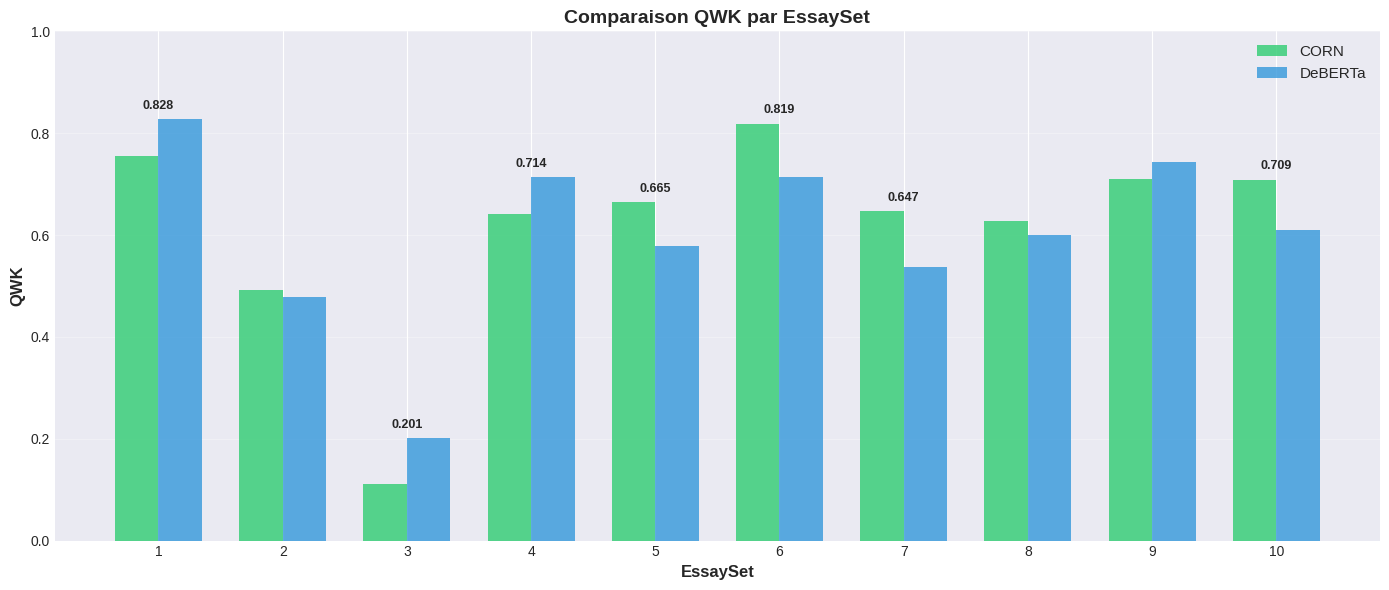

In [ ]:
# ══════════════════════════════════════════════════════════
# GRAPHIQUE 1 : Comparaison QWK par EssaySet
# ══════════════════════════════════════════════════════════

df_results = pd.DataFrame(results_by_es)

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(df_results))
width = 0.35

bars1 = ax.bar(x - width/2, df_results['corn_qwk'], width, label='CORN', color='#2ecc71', alpha=0.8)
bars2 = ax.bar(x + width/2, df_results['deb_qwk'], width, label='DeBERTa', color='#3498db', alpha=0.8)

ax.set_xlabel('EssaySet', fontsize=12, fontweight='bold')
ax.set_ylabel('QWK', fontsize=12, fontweight='bold')
ax.set_title('Comparaison QWK par EssaySet', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_results['essay_set'])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.0)

# Annotations
for i, (c, d) in enumerate(zip(df_results['corn_qwk'], df_results['deb_qwk'])):
    if abs(c - d) > 0.05:  # Annoter seulement si différence significative
        winner_val = max(c, d)
        ax.text(i, winner_val + 0.02, f'{winner_val:.3f}',
                ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


 Alignement des historiques CORN sur 11 époques (limité par l'arrêt le plus rapide).


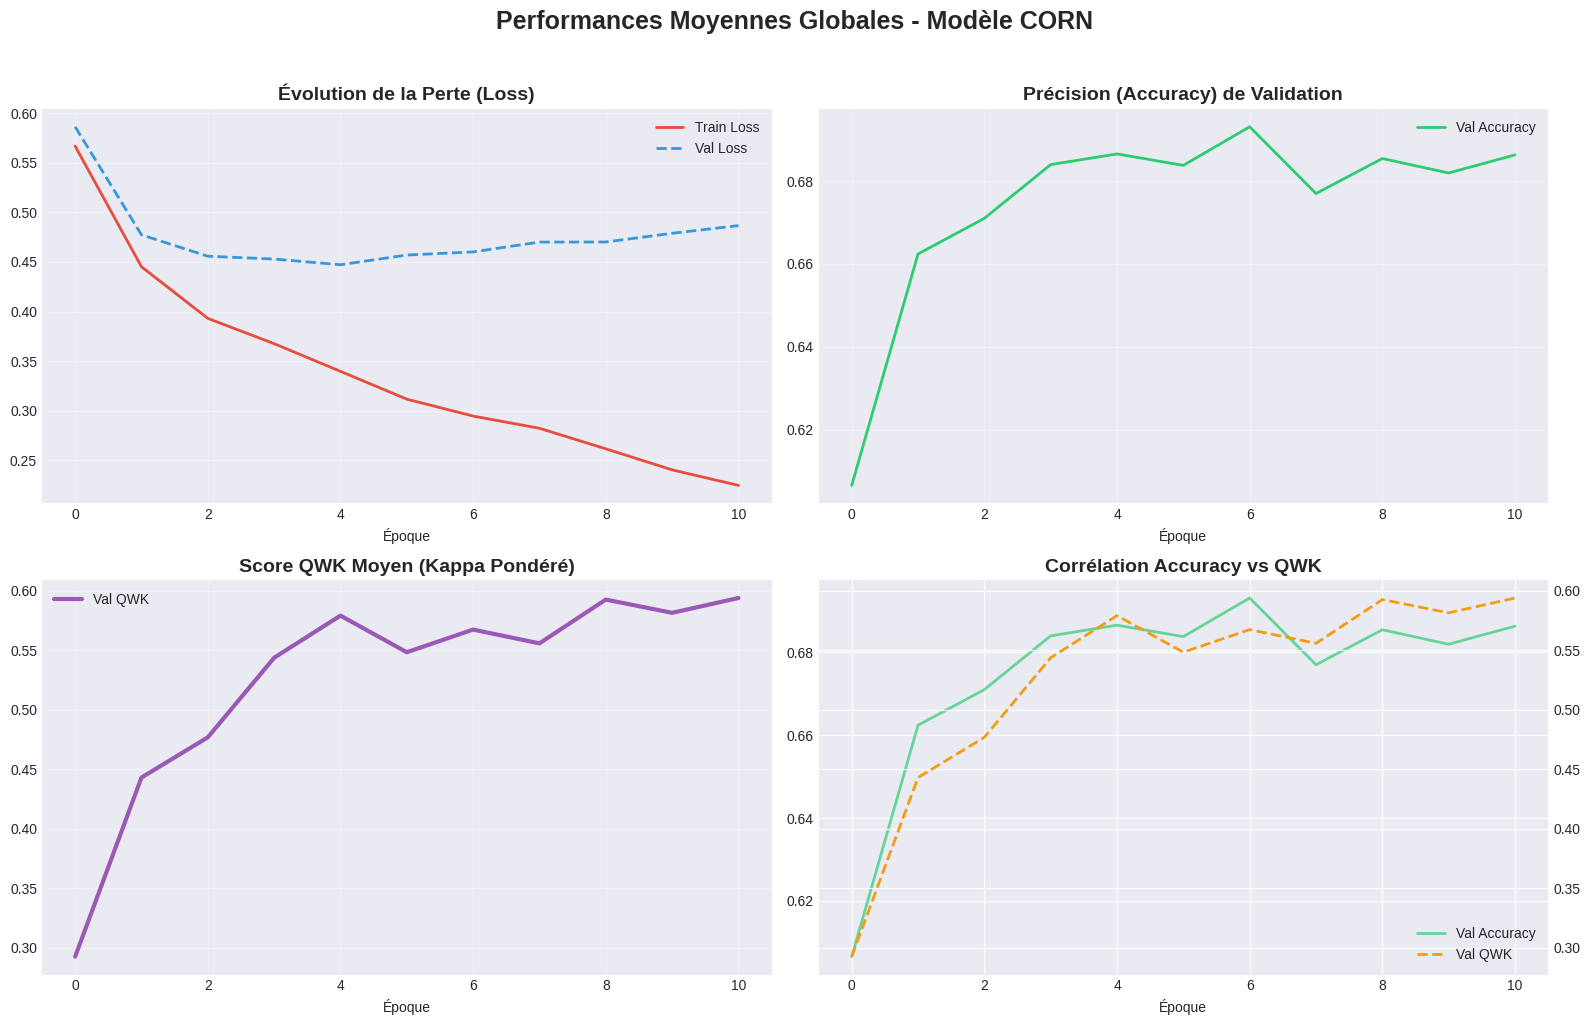

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- CHOIX DU DICTIONNAIRE ---
target_models = corn_models
model_name = "CORN" if target_models == corn_models else "DeBERTa"

# 1. Extraire les historiques et trouver la longueur minimale

all_histories = [data[1] for data in target_models.values()]

min_epochs = min(len(h['val_loss']) for h in all_histories)

print(f" Alignement des historiques {model_name} sur {min_epochs} époques (limité par l'arrêt le plus rapide).")

# 2. Calculer la moyenne uniquement sur ces époques communes
avg_hist = {}
# Liste des métriques présentes dans tes dictionnaires history
metrics = ['train_loss', 'val_loss', 'val_acc', 'val_qwk']

for key in metrics:
    # On tronque chaque historique à min_epochs pour pouvoir calculer la moyenne
    data_to_average = [h[key][:min_epochs] for h in all_histories]
    avg_hist[key] = np.mean(data_to_average, axis=0)

# ==========================================
# 3. VISUALISATION DES MOYENNES
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f"Performances Moyennes Globales - Modèle {model_name}", fontsize=18, fontweight='bold', y=1.02)

# Graphique 1: Loss (Train vs Val)
axes[0, 0].plot(avg_hist['train_loss'], linewidth=2, label='Train Loss', color='#e74c3c')
axes[0, 0].plot(avg_hist['val_loss'], linewidth=2, label='Val Loss', color='#3498db', linestyle='--')
axes[0, 0].set_title("Évolution de la Perte (Loss)", fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel("Époque")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Graphique 2: Accuracy Val
axes[0, 1].plot(avg_hist['val_acc'], linewidth=2, label='Val Accuracy', color='#2ecc71')
axes[0, 1].set_title("Précision (Accuracy) de Validation", fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel("Époque")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Graphique 3: QWK Moyen (Le plus important pour ce projet)
axes[1, 0].plot(avg_hist['val_qwk'], linewidth=3, label='Val QWK', color='#9b59b6')
axes[1, 0].set_title("Score QWK Moyen (Kappa Pondéré)", fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel("Époque")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Graphique 4: Comparaison Acc vs QWK
axes[1, 1].plot(avg_hist['val_acc'], linewidth=2, label='Val Accuracy', color='#2ecc71', alpha=0.7)
ax2 = axes[1, 1].twinx()
ax2.plot(avg_hist['val_qwk'], linewidth=2, label='Val QWK', color='#f39c12', linestyle='--')
axes[1, 1].set_title('Corrélation Accuracy vs QWK', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel("Époque")
# Fusion des légendes pour les deux axes
lines, labels = axes[1, 1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='lower right')

plt.tight_layout()
plt.show()


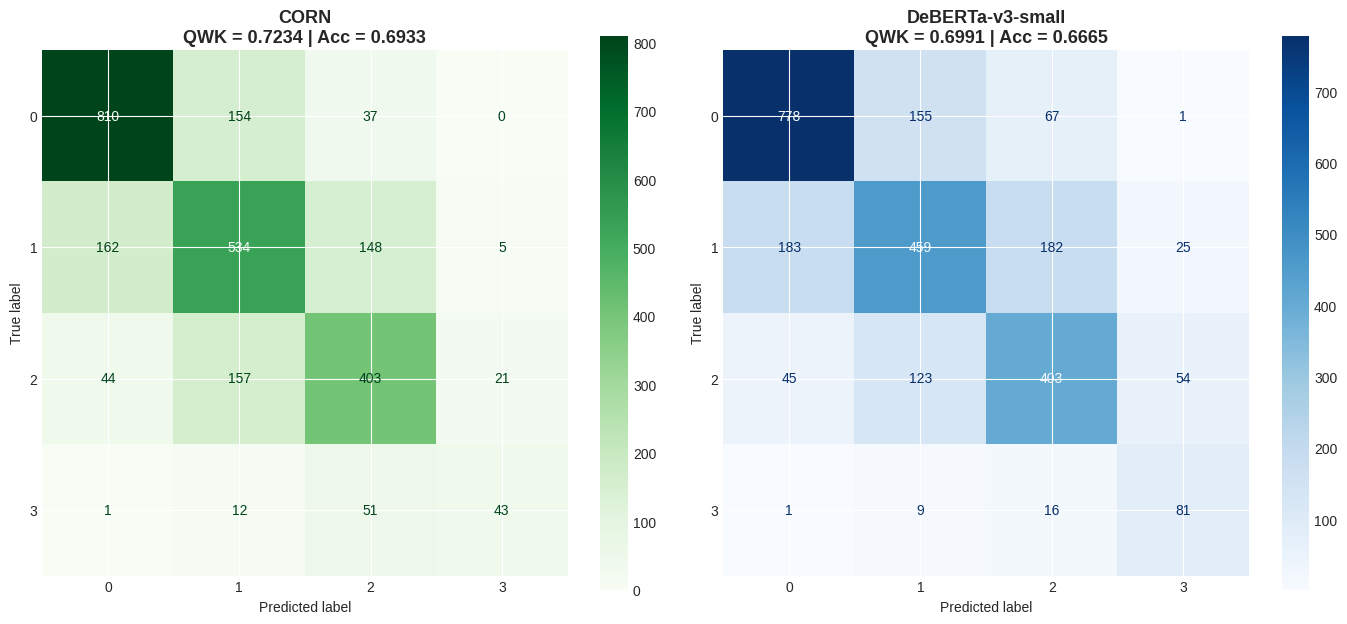


🔍 Analyse des erreurs:

CORN        :  792 erreurs ( 30.7%) | Erreurs extrêmes (Δ≥2):  99
DeBERTa     :  861 erreurs ( 33.3%) | Erreurs extrêmes (Δ≥2): 148


In [ ]:
# ══════════════════════════════════════════════════════════
# GRAPHIQUE 2 : Matrices de confusion côte à côte
# ══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# CORN
cm_corn = confusion_matrix(y_test, preds_corn_test, labels=[0,1,2,3])
disp_corn = ConfusionMatrixDisplay(cm_corn, display_labels=[0,1,2,3])
disp_corn.plot(ax=axes[0], cmap='Greens', values_format='d')
axes[0].set_title(f'CORN\nQWK = {qwk_corn:.4f} | Acc = {acc_corn:.4f}',
                  fontsize=13, fontweight='bold')

# DeBERTa
cm_deb = confusion_matrix(y_test, preds_deb_test, labels=[0,1,2,3])
disp_deb = ConfusionMatrixDisplay(cm_deb, display_labels=[0,1,2,3])
disp_deb.plot(ax=axes[1], cmap='Blues', values_format='d')
axes[1].set_title(f'DeBERTa-v3-small\nQWK = {qwk_deb:.4f} | Acc = {acc_deb:.4f}',
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Analyse des erreurs
print('\n🔍 Analyse des erreurs:\n')
for name, preds in [('CORN', preds_corn_test), ('DeBERTa', preds_deb_test)]:
    errors = preds != y_test
    extreme_errors = np.abs(preds - y_test) >= 2
    print(f'{name:12s}: {errors.sum():4d} erreurs ({errors.sum()/len(y_test)*100:5.1f}%) | '
          f'Erreurs extrêmes (Δ≥2): {extreme_errors.sum():3d}')


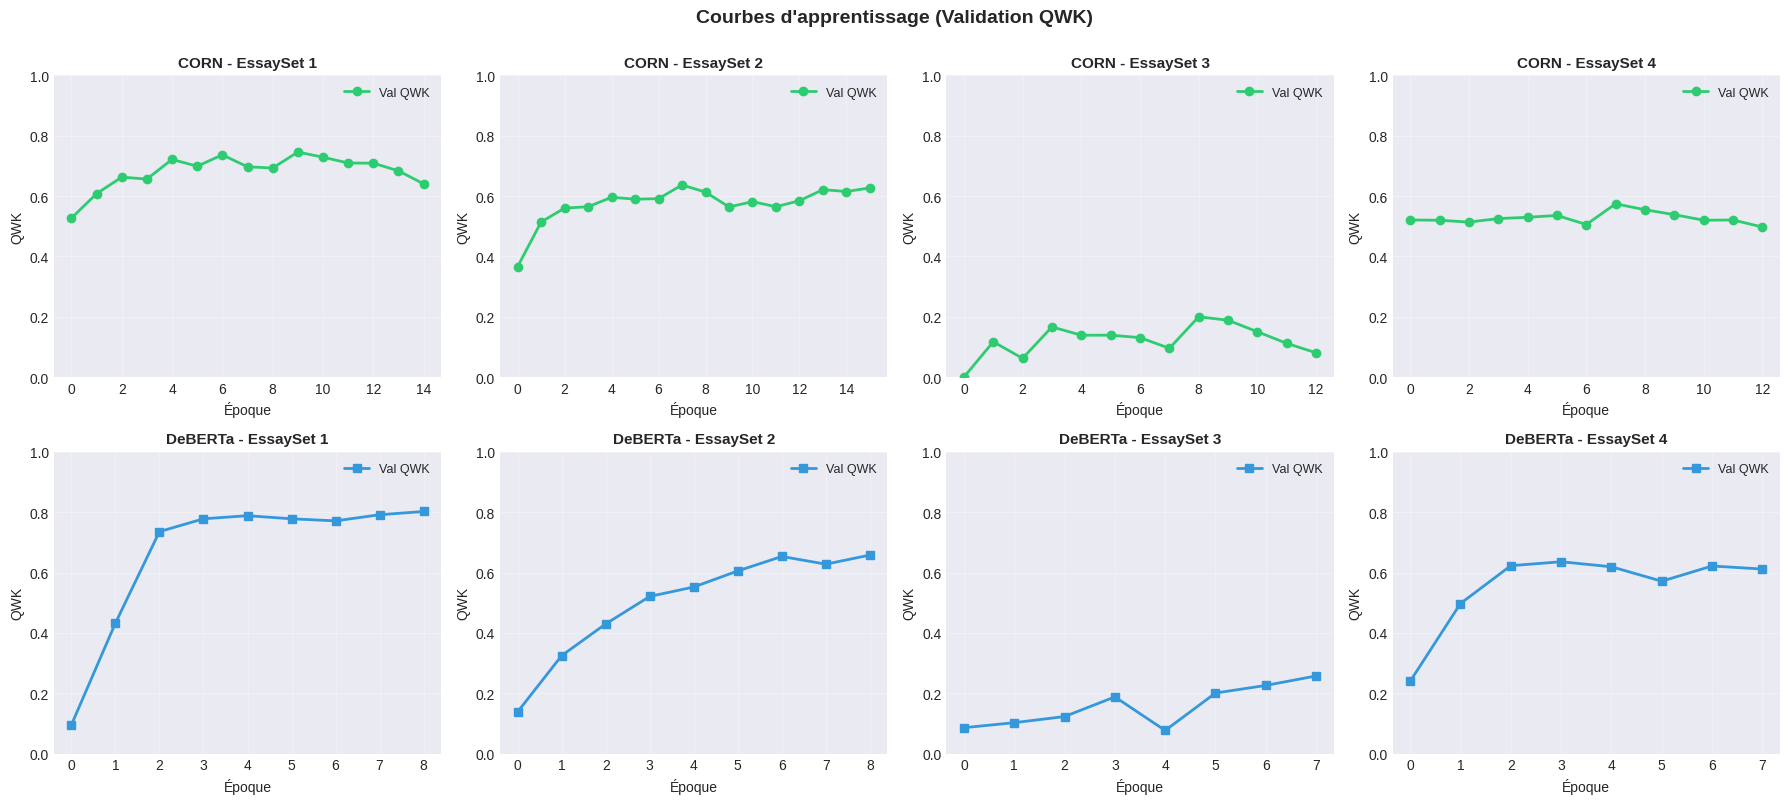

In [ ]:
# ══════════════════════════════════════════════════════════
# GRAPHIQUE 3 : Courbes d'entraînement
# ══════════════════════════════════════════════════════════

# Sélectionner 4 questions représentatives
selected_es = sorted(df_test['essay_set'].unique())[:4]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for idx, es in enumerate(selected_es):
    # CORN
    if es in corn_models:
        _, hist_c, _, _ = corn_models[es]
        ax = axes[0, idx]
        ax.plot(hist_c['val_qwk'], marker='o', color='#2ecc71', linewidth=2, label='Val QWK')
        ax.set_title(f'CORN - EssaySet {es}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Époque')
        ax.set_ylabel('QWK')
        ax.grid(alpha=0.3)
        ax.legend(fontsize=9)
        ax.set_ylim(0, 1.0)

    # DeBERTa
    if es in deberta_models:
        _, _, hist_d, _, _ = deberta_models[es]
        ax = axes[1, idx]
        ax.plot(hist_d['val_qwk'], marker='s', color='#3498db', linewidth=2, label='Val QWK')
        ax.set_title(f'DeBERTa - EssaySet {es}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Époque')
        ax.set_ylabel('QWK')
        ax.grid(alpha=0.3)
        ax.legend(fontsize=9)
        ax.set_ylim(0, 1.0)

plt.suptitle('Courbes d\'apprentissage (Validation QWK)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


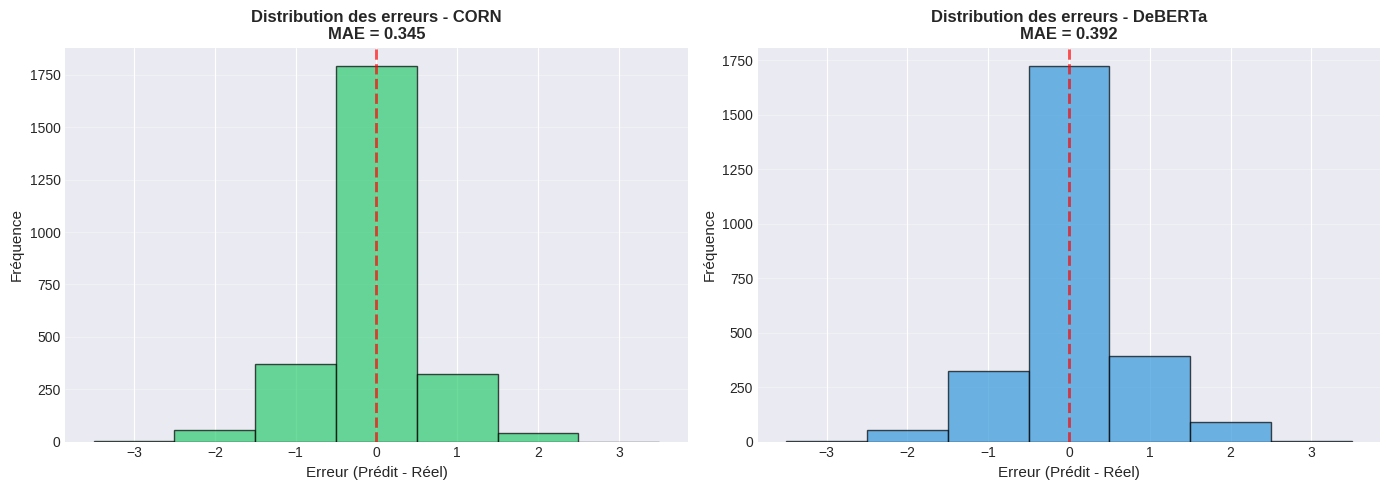

In [ ]:
# ══════════════════════════════════════════════════════════
# GRAPHIQUE 4 : Distribution des erreurs
# ══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Erreurs CORN
errors_corn = preds_corn_test - y_test
axes[0].hist(errors_corn, bins=np.arange(-3.5, 4.5, 1), color='#2ecc71', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Erreur (Prédit - Réel)', fontsize=11)
axes[0].set_ylabel('Fréquence', fontsize=11)
axes[0].set_title(f'Distribution des erreurs - CORN\nMAE = {np.abs(errors_corn).mean():.3f}',
                  fontsize=12, fontweight='bold')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[0].grid(axis='y', alpha=0.3)

# Erreurs DeBERTa
errors_deb = preds_deb_test - y_test
axes[1].hist(errors_deb, bins=np.arange(-3.5, 4.5, 1), color='#3498db', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Erreur (Prédit - Réel)', fontsize=11)
axes[1].set_ylabel('Fréquence', fontsize=11)
axes[1].set_title(f'Distribution des erreurs - DeBERTa\nMAE = {np.abs(errors_deb).mean():.3f}',
                  fontsize=12, fontweight='bold')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


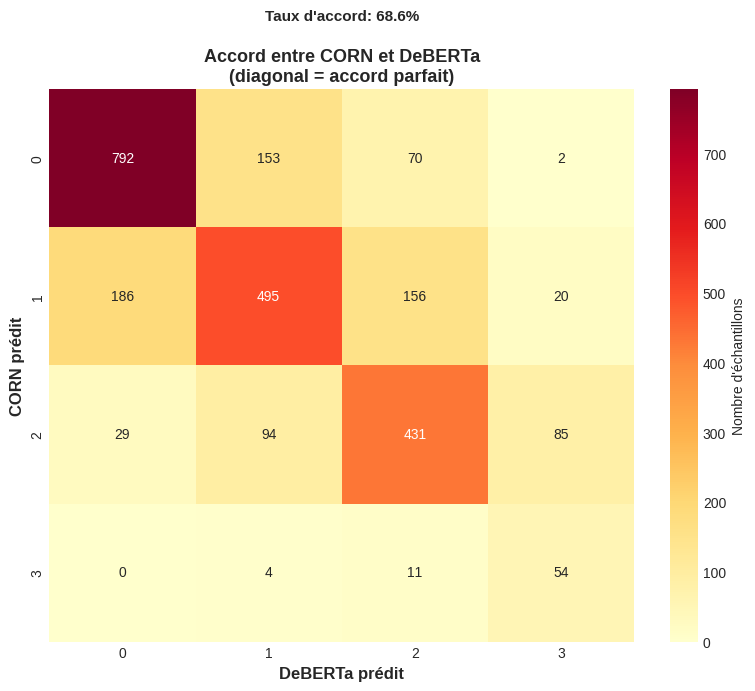

In [ ]:
# ══════════════════════════════════════════════════════════
# GRAPHIQUE 5 : Heatmap de comparaison
# ══════════════════════════════════════════════════════════

# Matrice : combien de fois CORN et DeBERTa prédisent la même chose
agreement_matrix = confusion_matrix(preds_corn_test, preds_deb_test, labels=[0,1,2,3])

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(agreement_matrix, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=[0,1,2,3], yticklabels=[0,1,2,3],
            cbar_kws={'label': 'Nombre d\'échantillons'})
ax.set_xlabel('DeBERTa prédit', fontsize=12, fontweight='bold')
ax.set_ylabel('CORN prédit', fontsize=12, fontweight='bold')
ax.set_title('Accord entre CORN et DeBERTa\n(diagonal = accord parfait)',
             fontsize=13, fontweight='bold')

# Taux d'accord
agreement_rate = (preds_corn_test == preds_deb_test).sum() / len(y_test)
ax.text(2, -0.5, f'Taux d\'accord: {agreement_rate*100:.1f}%',
        fontsize=11, fontweight='bold', ha='center')

plt.tight_layout()
plt.show()


## **12. Rapport de classification détaillé**


In [ ]:
print('='*70)
print(' RAPPORT DE CLASSIFICATION DÉTAILLÉ')
print('='*70)

print('\n CORN:\n')
print(classification_report(y_test, preds_corn_test,
                            target_names=['Score 0', 'Score 1', 'Score 2', 'Score 3']))

print('\n DeBERTa-v3-small:\n')
print(classification_report(y_test, preds_deb_test,
                            target_names=['Score 0', 'Score 1', 'Score 2', 'Score 3']))


 RAPPORT DE CLASSIFICATION DÉTAILLÉ

 CORN:

              precision    recall  f1-score   support

     Score 0       0.80      0.81      0.80      1001
     Score 1       0.62      0.63      0.63       849
     Score 2       0.63      0.64      0.64       625
     Score 3       0.62      0.40      0.49       107

    accuracy                           0.69      2582
   macro avg       0.67      0.62      0.64      2582
weighted avg       0.69      0.69      0.69      2582


 DeBERTa-v3-small:

              precision    recall  f1-score   support

     Score 0       0.77      0.78      0.77      1001
     Score 1       0.62      0.54      0.58       849
     Score 2       0.60      0.64      0.62       625
     Score 3       0.50      0.76      0.60       107

    accuracy                           0.67      2582
   macro avg       0.62      0.68      0.64      2582
weighted avg       0.67      0.67      0.67      2582



## **13. Conclusion**

### Points clés

1. **Entraînement par question** : Permet de respecter l'hétérogénéité des sujets (science vs littérature, rubrics différentes)

2. **CORN (Régression ordinale)** :
   - Exploite la structure ordinale des scores
   - Réduit les erreurs extrêmes (0↔3)
   - Entraînement rapide avec SBERT figé

3. **DeBERTa-v3-small** :
   - Encodeur adapté à la tâche via fine-tuning
   - Capture mieux les nuances linguistiques
   - Plus coûteux en temps et mémoire


